In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


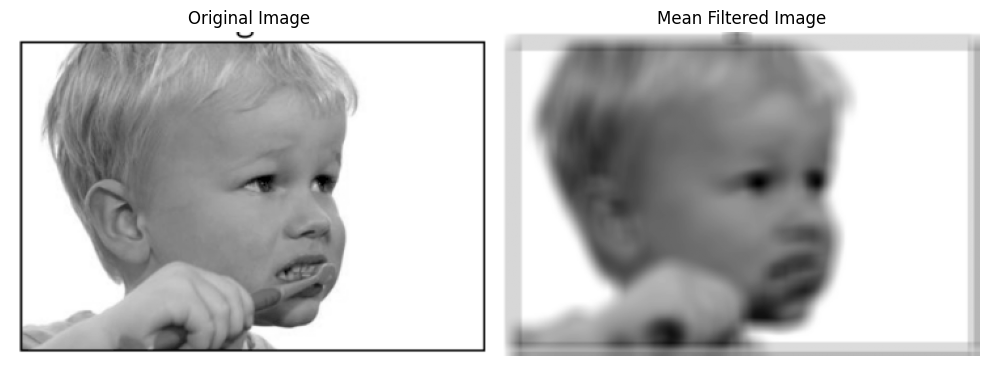

In [2]:
#Apply Linear shift-invariant image filtering on the image
# 1.MEAN FILTERING
import cv2
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt
# Read the image
path=r'/content/drive/MyDrive/CVClassLectureDemo/child.PNG'
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from path: {path}")
else:
    # Apply Mean Filter on Image
    # print(image.shape)
    kernel_size = 13

    # Define the kernel size for the mean filter (should be odd)
    # Apply the mean filter
    #A Mean Filter replaces each pixel with the average of its neighboring pixels.
    #This smooths the image and reduces random noise, but it also softens edges because sharp intensity changes are averaged out.
    blurred_image = cv2.blur(image, (kernel_size, kernel_size))

    # Display the original and blurred images


    plt.figure(figsize=(10, 5))

    plt.subplot(121), plt.imshow(image, cmap='gray')
    plt.title('Original Image'), plt.axis('off')

    plt.subplot(122), plt.imshow(blurred_image, cmap='gray')
    plt.title('Mean Filtered Image'), plt.axis('off')

    plt.tight_layout()
    plt.show()

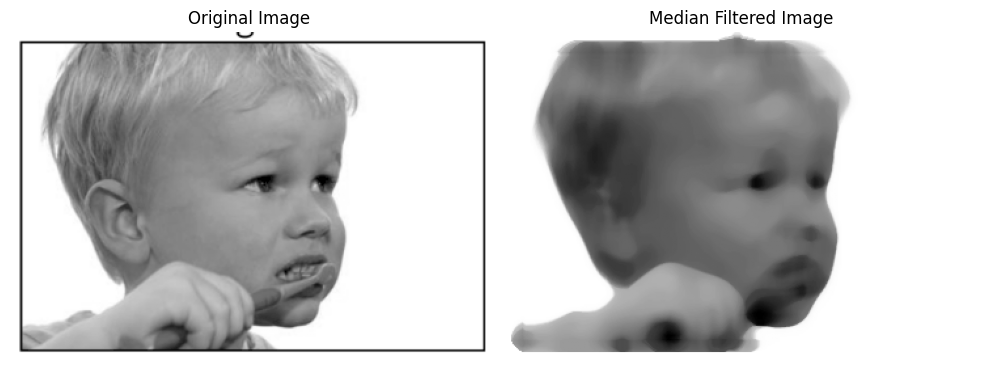

In [3]:
# Apply Median Filter on Image

# Define the kernel size for the median filter (should be odd)
kernel_size = 17

# Apply the median filter
#A Median Filter is an image processing technique used to remove noise from an image while preserving the edges.
blurred_image = cv2.medianBlur(image, kernel_size)

# Display the original and blurred images


plt.figure(figsize=(10, 5))

plt.subplot(121), plt.imshow(image, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(122), plt.imshow(blurred_image, cmap='gray')
plt.title('Median Filtered Image'), plt.axis('off')

plt.tight_layout()
plt.show()


**convolve image with Gaussian Kernel **

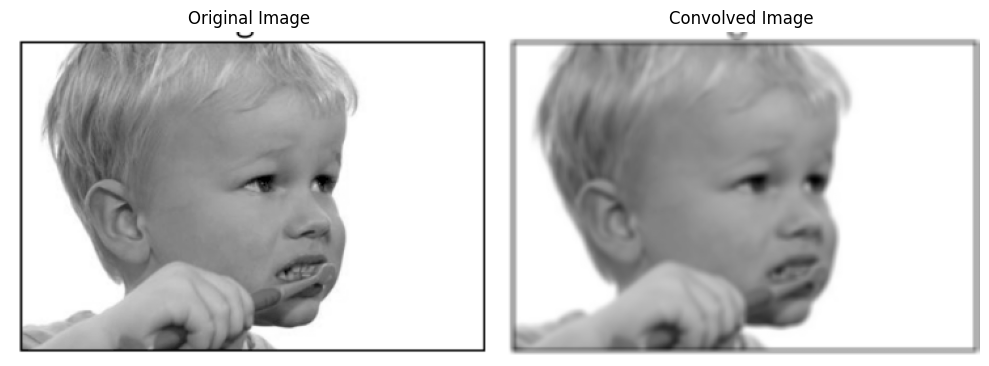

In [4]:
# Define the size and sigma of the Gaussian kernel
kernel_size = (5, 5)  # Adjust the kernel size as needed
sigma = 7  # Adjust the sigma value for Gaussian blur

# Create the Gaussian kernel
gaussian_kernel = cv2.getGaussianKernel(kernel_size[0], sigma)
gaussian_kernel = gaussian_kernel @ gaussian_kernel.T  # Creating a 2D Gaussian kernel

# Apply Gaussian blur to the image
#A Gaussian Blur is an image smoothing technique that reduces noise and fine details by
#giving more importance to nearby pixels and less importance to pixels farther away.
blurred_image = cv2.filter2D(image, -1, gaussian_kernel)

# Display the original and blurred images


plt.figure(figsize=(10, 5))

plt.subplot(121), plt.imshow(image, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(122), plt.imshow(blurred_image, cmap='gray')
plt.title('Convolved Image'), plt.axis('off')

plt.tight_layout()
plt.show()

Seperable Filter:3x3 Box Filter

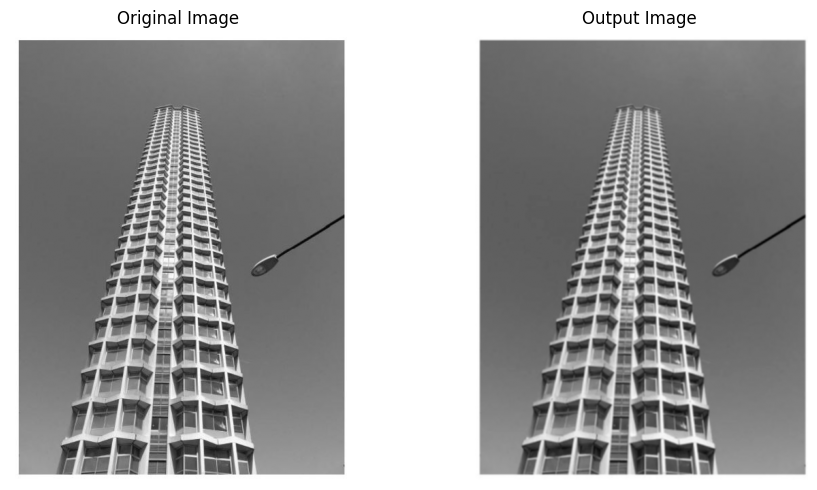

In [5]:
import cv2
import numpy as np

def box_filter(image):
    # Define a 3x3 box filter kernel
    #Box Filter is a filtering technique used to blur or smooth an image by averaging neighboring pixels.
    kernel = np.ones((3, 3), np.float32) / 9.0  # Normalizing to keep the sum of kernel elements to 1

    # Apply the box filter
    result = cv2.filter2D(image, -1, kernel)

    return result

# Example usage:
if __name__ == "__main__":
    # Load an image
    path=r'/content/drive/MyDrive/CVClassLectureDemo/tower.JPG'
    input_image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    #input_image = cv2.imread("tower.JPG", cv2.IMREAD_GRAYSCALE)

    # Define separable filter kernels (example: Sobel filter)
    kernel_x = np.array([[-1, 0, 1]])
    kernel_y = np.array([[-1], [0], [1]])

    # Apply the separable filter
    output_image = box_filter(input_image)
    cv2.imwrite('blur_img.jpg', output_image)
    # Display the original and filtered images
    plt.figure(figsize=(10, 5))

plt.subplot(121), plt.imshow(input_image, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(122), plt.imshow(output_image, cmap='gray')
plt.title('Output Image'), plt.axis('off')

plt.tight_layout()
plt.show()



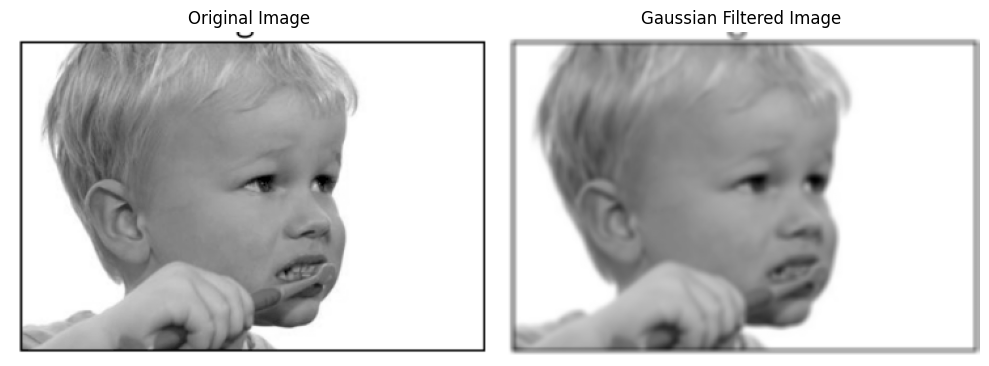

In [6]:
 #Apply Gaussian Filter on Image

# Apply Gaussian blur
blurred_image = cv2.GaussianBlur(image, (5, 5), 3)  # Adjust kernel size (here: 5x5) as needed
# Display the original and blurred images


plt.figure(figsize=(10, 5))

plt.subplot(121), plt.imshow(image, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(122), plt.imshow(blurred_image, cmap='gray')
plt.title('Gaussian Filtered Image'), plt.axis('off')

plt.tight_layout()
plt.show()#

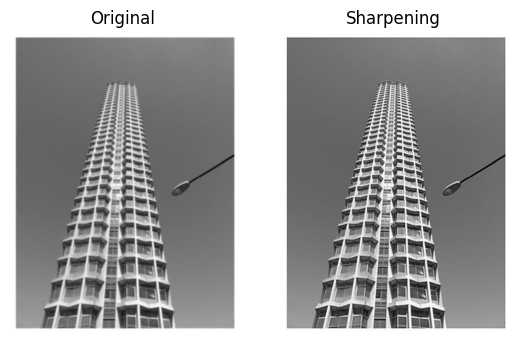

In [7]:
#Image Sharpening

# load the required packages
import cv2
import numpy as np

# load the image into system memory
    #image = cv2.imread('blur_img.jpg', flags=cv2.IMREAD_COLOR)
path=r'/content/drive/MyDrive/CVClassLectureDemo/blur_img.JPG'
    #image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
image = cv2.imread('blur_img.jpg', flags=cv2.IMREAD_COLOR)
#We will thereafter display the contents of the variable storing the image, to the screen:


#Below is the Python code we will use for sharpening the image:

#Plot the original image
plt.subplot(1, 2, 1)
plt.title("Original") , plt.axis('off')
plt.imshow(image)

# Create the sharpening kernel
kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])

# Sharpen the image
sharpened_image = cv2.filter2D(image, -1, kernel)

#Save the image
#cv2.imwrite('sharpened_image.jpg', sharpened_image)

#Plot the sharpened image
plt.subplot(1, 2, 2)
plt.title("Sharpening"), plt.axis('off')
plt.imshow(sharpened_image)
plt.show()

Original Image


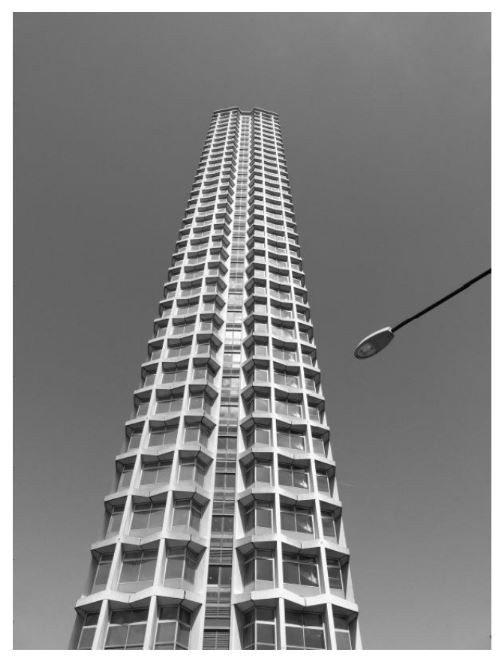

Sobel X


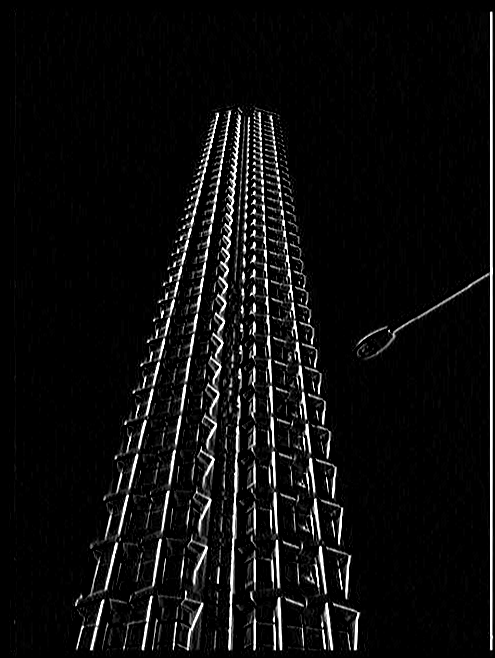

Sobel Y


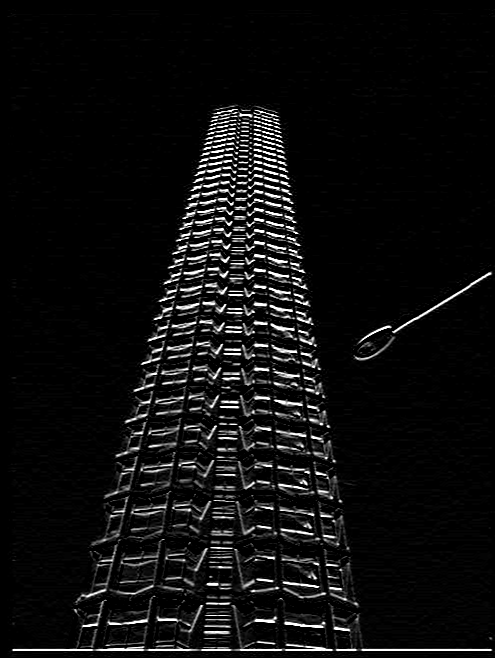

Sobel Combined


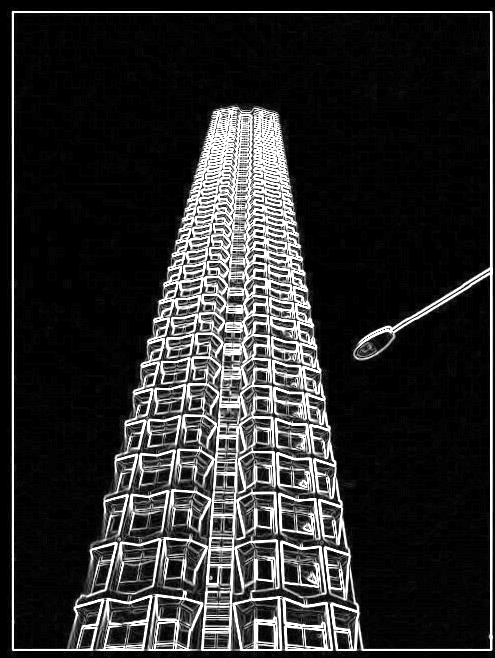

In [8]:
# Apply Sobel filters for edge detection
#cv2.Sobel(original_image,ddepth,xorder,yorder,kernelsize)
#path='tower.JPG'
path=r'/content/drive/MyDrive/CVClassLectureDemo/tower.JPG'
    #image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
#image = cv2.imread('blur_img.jpg', flags=cv2.IMREAD_COLOR)

#The Sobel Filter is one of the most important edge detection operators in Computer Vision.
#It is used to detect edges in an image by finding areas where the pixel intensity changes rapidly
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)


# Display the original and filtered image
print('Original Image')
cv2_imshow(image)
print('Sobel X')
cv2_imshow(sobel_x)
print('Sobel Y')
cv2_imshow(sobel_y)
print('Sobel Combined')
cv2_imshow(sobel_combined)

The Laplacian of Gaussian (LoG) filter is a technique used for edge detection and involves convolving an image with a Gaussian filter followed by the Laplacian filter.


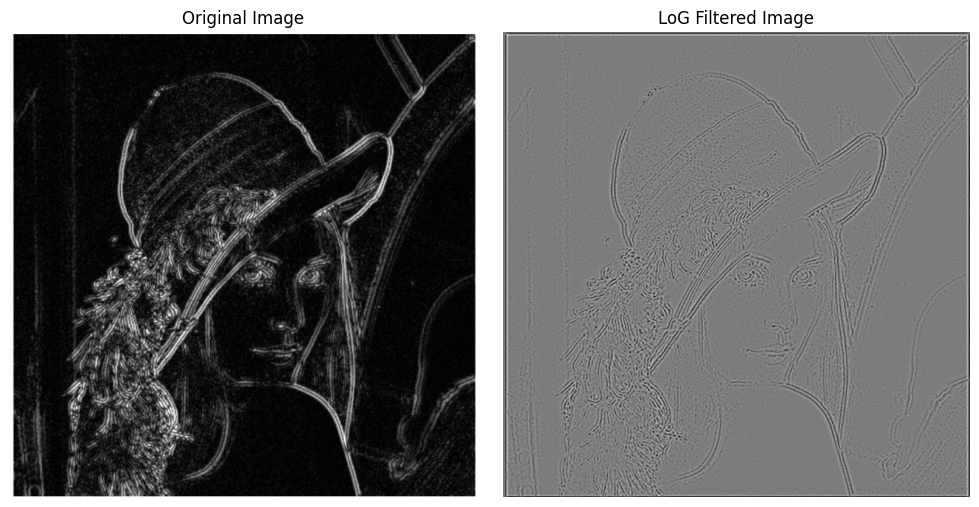

In [9]:
# apply Laplacian of Gaussian (LoG) filter on an image
#The Laplacian of Gaussian (LoG) is an edge detection technique that combines two operations:
#Gaussian Blur that Removes noise from the image.
#Laplacian Filter that Detects edges.
# Read the image
#path = 'lena.tif'
path=r'/content/drive/MyDrive/CVClassLectureDemo/lena_g.JPG'
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE) # Replace path with your image filename

# Apply GaussianBlur to the image
blurred = cv2.GaussianBlur(image, (3, 3), 1)  # You can adjust the kernel size (5, 5) and sigma value (0) as needed

# Apply the Laplacian operator after Gaussian blurring to get the LoG filter effect
log = cv2.Laplacian(blurred, cv2.CV_64F)
print('The Laplacian of Gaussian (LoG) filter is a technique used for edge detection and involves convolving an image with a Gaussian filter followed by the Laplacian filter.')

# Display the original image and the LoG-filtered image using matplotlib
plt.figure(figsize=(10, 5))

plt.subplot(121), plt.imshow(image, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(122), plt.imshow(log, cmap='gray')
plt.title('LoG Filtered Image'), plt.axis('off')

plt.tight_layout()
plt.show()


The Derivative of Gaussian (DoG) filter is used for edge detection in images.


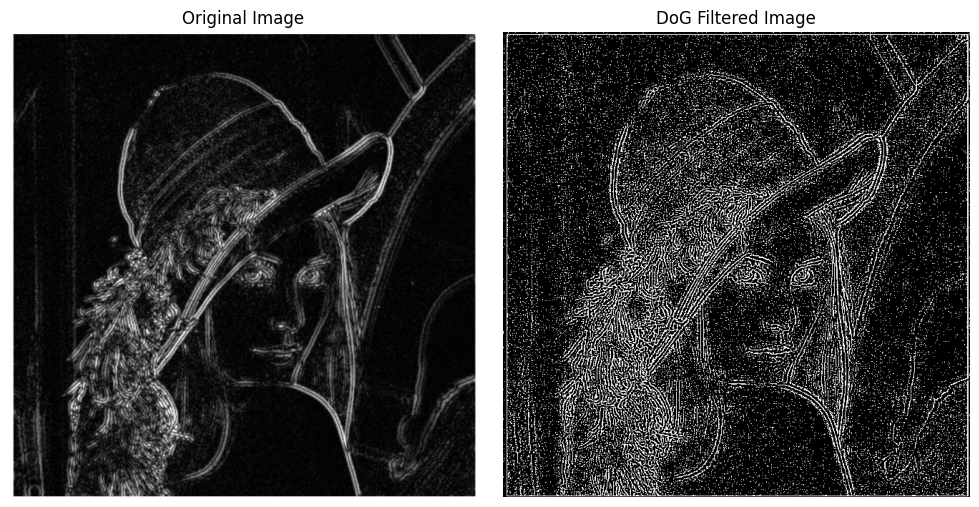

In [10]:
# Read the image
#path = 'lena.tif'
path=r'/content/drive/MyDrive/CVClassLectureDemo/lena_g.JPG'
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE) # Replace path with your image filename

# Difference of Gaussians (DoG) is a feature enhancement algorithm that involves the subtraction of one Gaussian blurred version
#of an original image from another, less blurred version of the original.
print('The Derivative of Gaussian (DoG) filter is used for edge detection in images.')

# Define two Gaussian kernels with different sigma values
sigma_1 = 1.3
sigma_2 = 3.0

# Apply GaussianBlur with the two sigma values
gaussian_1 = cv2.GaussianBlur(image, (3, 3), sigmaX=sigma_1)
gaussian_2 = cv2.GaussianBlur(image, (3, 3), sigmaX=sigma_2)

# Calculate the DoG by subtracting the blurred images
dog = gaussian_1 - gaussian_2

# Display the original image and the DoG-filtered image using matplotlib
plt.figure(figsize=(10, 5))

plt.subplot(121), plt.imshow(image, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(122), plt.imshow(dog, cmap='gray')
plt.title('DoG Filtered Image'), plt.axis('off')

plt.tight_layout()
plt.show()

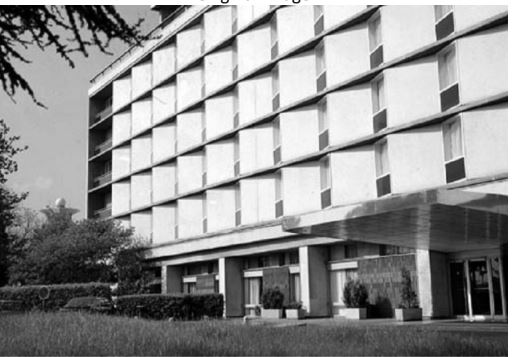

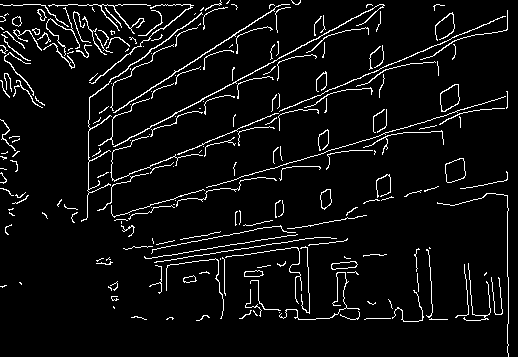

In [11]:
import cv2
import numpy as np

# Read the image
#image = cv2.imread('canny.JPG')
path=r'/content/drive/MyDrive/CVClassLectureDemo/canny.JPG'
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE) # Replace path with your image filename
# Convert the image to grayscale
#gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray=image
# Apply Gaussian blur to reduce noise and smoothen edges
blur = cv2.GaussianBlur(gray, (7, 7), 0)

# Perform Canny edge detection
#Its purpose is to detect only the real edges in an image while removing noise and avoiding false edges.
edges = cv2.Canny(blur, 150, 200)

# Display the edges
cv2_imshow(image)
cv2_imshow(edges)
cv2.waitKey(0)
cv2.destroyAllWindows()

Input


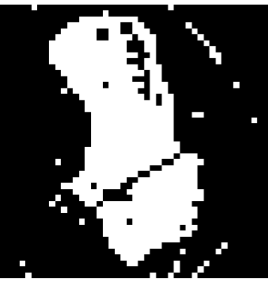

K erosion


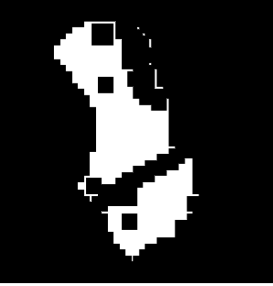

Erosion-Dilation


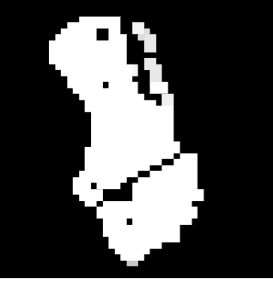

K dilation


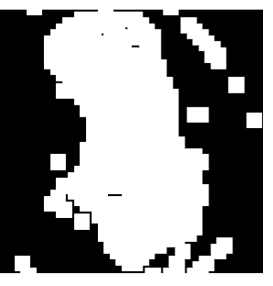

closing_opening


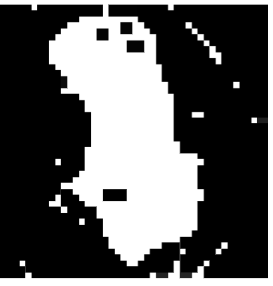

Opening


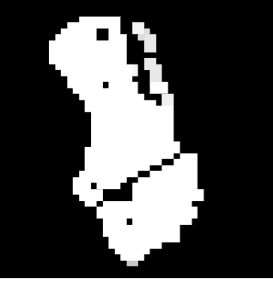

Closing


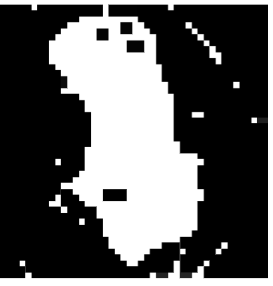

In [12]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

# Read the input image
path=r'/content/drive/MyDrive/CVClassLectureDemo/bone.PNG'
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
#image = cv2.imread('bone.PNG', cv2.IMREAD_GRAYSCALE)
print("Input")
cv2_imshow(image)
# Define the number of erosions and dilations
k = 5

# Create a 3x3 square structuring element
structuring_element_3x3 = np.ones((3, 3), np.uint8)

# Create a (2k+1)x(2k+1) square structuring element for opening and closing
structuring_element_kxk = np.ones((2*k + 1, 2*k + 1), np.uint8)

# Perform k erosions followed by k dilations
erosion = cv2.erode(image, structuring_element_3x3, iterations=k)
print("K erosion")
cv2_imshow(erosion)
opening_closing = cv2.dilate(erosion, structuring_element_3x3, iterations=k)
print("Erosion-Dilation")
cv2_imshow(opening_closing)

# Perform k dilations followed by k erosions
dilation = cv2.dilate(image, structuring_element_3x3, iterations=k)
print("K dilation")
cv2_imshow(dilation)
closing_opening = cv2.erode(dilation, structuring_element_3x3, iterations=k)
print("closing_opening")
cv2_imshow(closing_opening)

# Perform opening with a (2k+1)x(2k+1) square
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, structuring_element_kxk)

# Perform closing with a (2k+1)x(2k+1) square
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, structuring_element_kxk)

# Display the results




print("Opening")
cv2_imshow(opening)
print("Closing")
cv2_imshow(closing)




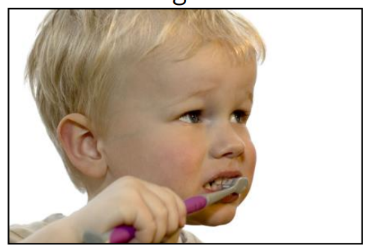

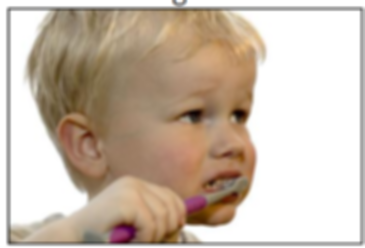

In [17]:
from google.colab.patches import cv2_imshow
import cv2

img = cv2.imread("/content/drive/MyDrive/CVClassLectureDemo/child.PNG")   # BGR image

blur = cv2.GaussianBlur(img, (5,5), 2)

cv2_imshow(img)
cv2_imshow(blur)

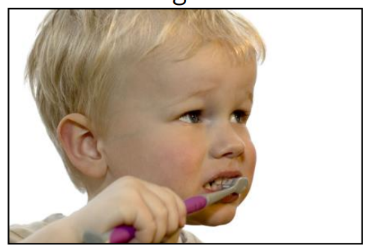

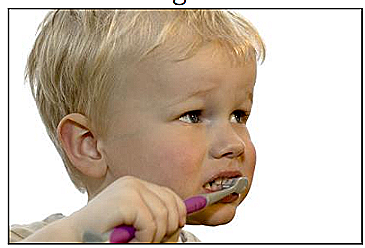

In [19]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

img = cv2.imread("/content/drive/MyDrive/CVClassLectureDemo/child.PNG")

kernel = np.array([[0,-1,0],
                   [-1,5,-1],
                   [0,-1,0]])

sharp = cv2.filter2D(img, -1, kernel)

cv2_imshow(img)
cv2_imshow(sharp)

In [20]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)

Original Grayscale Image


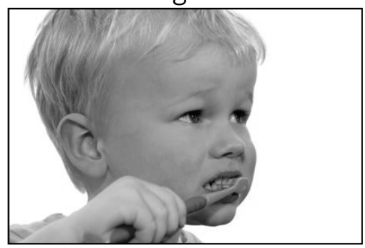

Sobel X Image


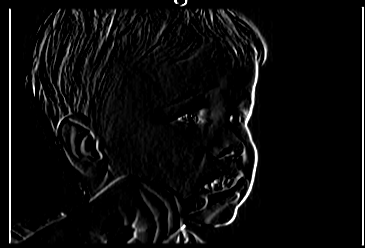

Sobel Y Image


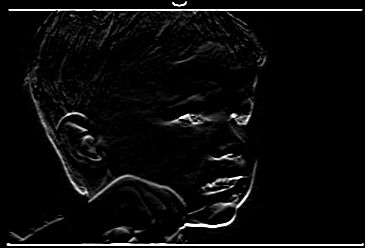

In [23]:
from google.colab.patches import cv2_imshow
import cv2

img = cv2.imread("/content/drive/MyDrive/CVClassLectureDemo/child.PNG")

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
sobel_x = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)

# Display the results
print('Original Grayscale Image')
cv2_imshow(gray_img)
print('Sobel X Image')
cv2_imshow(sobel_x)
print('Sobel Y Image')
cv2_imshow(sobel_y)

Original Image:


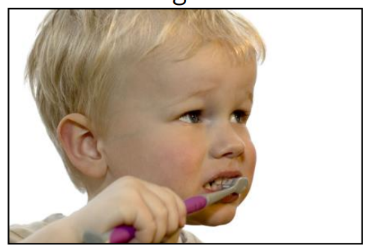

Dilated Image:


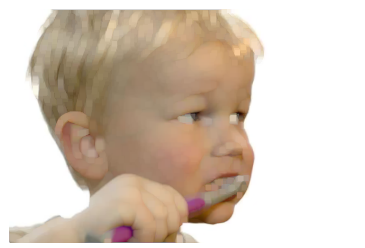

Eroded Image:


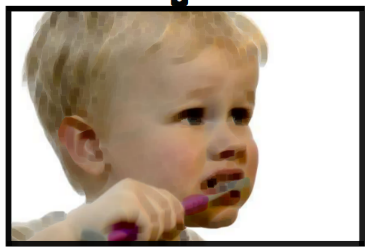

In [25]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np

# Load the image
# Assuming 'img' is available from a previous cell, or load it here if not.
# For demonstration, I'll load it explicitly to make the cell self-contained.
img = cv2.imread("/content/drive/MyDrive/CVClassLectureDemo/child.PNG")

kernel = np.ones((5,5), np.uint8)

dilation = cv2.dilate(img, kernel, iterations=1)
erosion = cv2.erode(img, kernel, iterations=1)

print('Original Image:')
cv2_imshow(img)
print('Dilated Image:')
cv2_imshow(dilation)
print('Eroded Image:')
cv2_imshow(erosion)

Original Image:


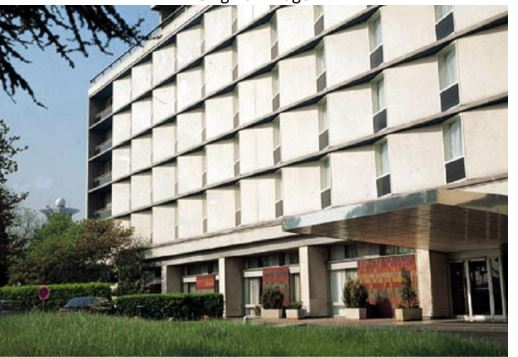

Processed Image (L-channel blurred):


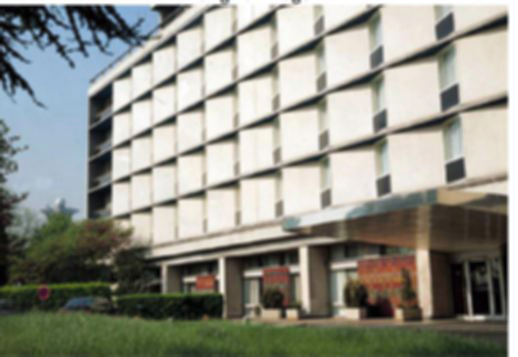

In [27]:
from google.colab.patches import cv2_imshow
import cv2

img = cv2.imread("/content/drive/MyDrive/CVClassLectureDemo/canny.JPG")

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

# Blur only the L (lightness) channel
L, A, B = cv2.split(lab)

L = cv2.GaussianBlur(L, (5,5), 2)

lab = cv2.merge((L, A, B))
result = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

print('Original Image:')
cv2_imshow(img)
print('Processed Image (L-channel blurred):')
cv2_imshow(result)